## View human learning curves from Experiment 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from hobj.benchmarks import MutatorHighVarBenchmark
benchmark1 = MutatorHighVarBenchmark()
target_statistics = benchmark1.target_statistics
print(target_statistics)

<xarray.LearningCurveStatistics> Size: 103MB
Dimensions:           (subtask: 64, trial: 100, boot_iter: 1000)
Coordinates:
  * subtask           (subtask) <U35 9kB 'MutatorB2000_0,MutatorB2000_4718' ....
Dimensions without coordinates: trial, boot_iter
Data variables:
    phat              (subtask, trial) float64 51kB 0.44 0.68 0.62 ... 0.68 0.86
    varhat_phat       (subtask, trial) float64 51kB 0.005029 ... 0.002457
    boot_phat         (boot_iter, subtask, trial) float64 51MB 0.5 0.68 ... 0.78
    boot_varhat_phat  (boot_iter, subtask, trial) float64 51MB 0.005102 ... 0...


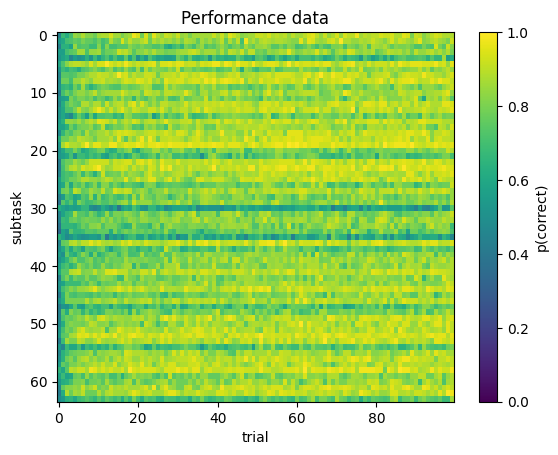

In [3]:
# Plot the [subtask, trial] performance data
plt.figure()
plt.imshow(target_statistics.phat, aspect='auto', cmap = 'viridis', vmin = 0, vmax = 1)
plt.xlabel('trial')
plt.ylabel('subtask')
plt.title("Performance data")
plt.colorbar(label='p(correct)')
plt.show()


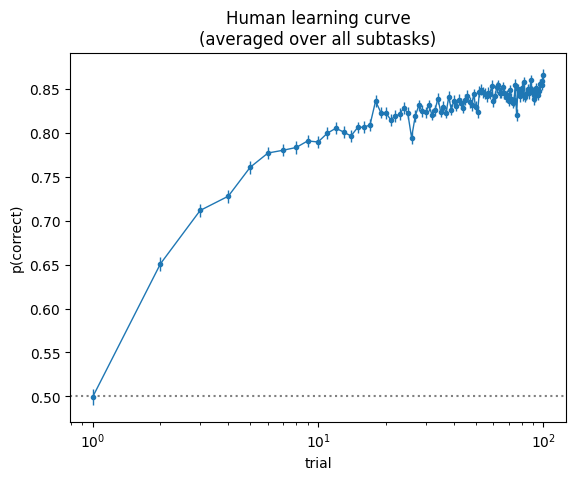

In [4]:
# Calculate the subtask-averaged learning curve
glc = target_statistics.phat.mean('subtask')

# Compute standard error using the bootstrap samples:
glc_se = target_statistics.boot_phat.mean('subtask').std('boot_iter', ddof = 1) 

plt.figure()
plt.errorbar(np.arange(len(glc))+1, glc, yerr = glc_se,  lw = 1, elinewidth = 1, marker = '.')
plt.axhline(0.5, ls = ':', color = 'gray')
plt.xscale('log')
plt.xlabel('trial')
plt.ylabel('p(correct)')
plt.title("Human learning curve\n(averaged over all subtasks)")
plt.show()